In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# 把 deeplearning 目录加入模块搜索路径
d2l_dir = Path(r"C:\Users\abc\Documents\GitHub\vscodepractice\deeplearning")
sys.path.insert(0, str(d2l_dir))
import math
import numpy as np
import torch
from torch import nn
import d2l_local as d2l

In [2]:
net = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(4096, 10))

In [3]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

In [4]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)

loss 0.331, train acc 0.880, test acc 0.881
1486.8 examples/sec on cuda:0


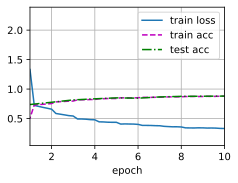

In [5]:
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

In [10]:
net1 = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),#13
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(32, 64, kernel_size=3, padding=2), nn.ReLU(),#15
    nn.MaxPool2d(kernel_size=3, stride=2),#7
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),#7
    nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU(),#7
    nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.ReLU(),#7
    nn.MaxPool2d(kernel_size=3, stride=2),#3
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(288, 2048), nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(2048, 1024), nn.ReLU(),
    nn.Dropout(p=0.3),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(1024, 10))

In [11]:
X = torch.randn(1, 1, 28, 28)
for layer in net1:
    X=layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 32, 28, 28])
ReLU output shape:	 torch.Size([1, 32, 28, 28])
MaxPool2d output shape:	 torch.Size([1, 32, 13, 13])
Conv2d output shape:	 torch.Size([1, 64, 15, 15])
ReLU output shape:	 torch.Size([1, 64, 15, 15])
MaxPool2d output shape:	 torch.Size([1, 64, 7, 7])
Conv2d output shape:	 torch.Size([1, 128, 7, 7])
ReLU output shape:	 torch.Size([1, 128, 7, 7])
Conv2d output shape:	 torch.Size([1, 64, 7, 7])
ReLU output shape:	 torch.Size([1, 64, 7, 7])
Conv2d output shape:	 torch.Size([1, 32, 7, 7])
ReLU output shape:	 torch.Size([1, 32, 7, 7])
MaxPool2d output shape:	 torch.Size([1, 32, 3, 3])
Flatten output shape:	 torch.Size([1, 288])
Linear output shape:	 torch.Size([1, 2048])
ReLU output shape:	 torch.Size([1, 2048])
Dropout output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 1024])
ReLU output shape:	 torch.Size([1, 1024])
Dropout output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


In [12]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

loss 0.370, train acc 0.862, test acc 0.862
18640.1 examples/sec on cuda:0


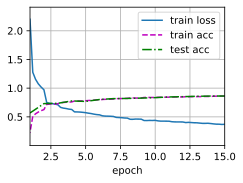

In [14]:
lr, num_epochs = 0.01, 15
d2l.train_ch6(net1, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())